In [13]:
import os
import gpflow
from scipy.stats import qmc, norm, dirichlet
from tqdm import tqdm
import rich
from rich.progress import Progress, BarColumn, TaskProgressColumn, TimeRemainingColumn, TextColumn
from rich.live import Live
from rich.table import Table
from rich.console import Group
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from wrap_c_lib import load_c_lib
nb_root = os.path.abspath(os.getcwd())
xgb_clf = load_c_lib(os.path.join(nb_root, 'xgb_classifier.so'))
xgb_reg = load_c_lib(os.path.join(nb_root, 'xgb_regressor.so'))

df = pd.read_csv('sample_tutorial.csv')

In [8]:
cutoff = 10

def chi2_fake(points):
  x = np.zeros((points.shape[0], 6))
  x[:,:2] = points[:,:]
  x[:,1] /= 10**x[:,0]
  res = np.where(xgb_clf(x) > 0, xgb_reg(x), np.min(df['chi2']) + cutoff - xgb_clf(x))
  return res.astype(np.float64)

We create the initial points, randomly distributed

In [9]:
lhs = qmc.LatinHypercube(d=2)

X = lhs.random(200)
X[:,0] = X[:,0]*2 + 6
X[:,1] = 3* X[:,1]

y = chi2_fake(X)

In [10]:
def expected_improvement(X_candidates, model, y_best, delta=0.1):
    mu, sigma = model.predict_y(X_candidates)
    mu = mu.numpy().flatten()
    sigma = sigma.numpy().flatten()
    I = (y_best - mu - delta) / (sigma + 1e-10)
    ei = sigma * (I* norm.cdf(I) + norm.pdf(I))
    ei[sigma < 1e-10] = 0.0
    return ei

In [11]:
def make_display(progress, info):
  table = Table.grid(padding=(0,2))
  table.add_column(style='bold')
  table.add_column(justify='right')
  table.add_row('Best chi2', f'{info["best"]:.4f}')
  table.add_row('New point', f'{info["new"]:.4f}')
  table.add_row('GP prediction', f'{info["pred"]:.4f}')
  table.add_row('GP sigma', f'{info["sigma"]:.4f}')
  table.add_row('delta', f'{info["delta"]:.4f}')
  return Group(progress, table)

delta = np.std(y)

progress = Progress(
    TextColumn("{task.description}"),
    BarColumn(),
    TaskProgressColumn(),
    TextColumn("|"),
    TimeRemainingColumn(),
)

info = {'best': np.inf, 'new': np.inf, 'pred': np.inf, 'sigma': np.inf, 'delta': delta}

n_Newpoints = 300

task = progress.add_task("Generate training points", total=n_Newpoints)

opt = gpflow.optimizers.Scipy()

with Live(make_display(progress, info), refresh_per_second=2) as live:
  for _ in range(n_Newpoints):
    gp = gpflow.models.GPR(data=(X, y[:,None]), kernel=gpflow.kernels.SquaredExponential())
    opt.minimize(gp.training_loss, gp.trainable_variables)

    # Random candidates from Latin Hypersquare
    candidates = lhs.random(15000)
    candidates[:,0] = candidates[:,0]*2 + 6
    candidates[:,1] = 3* candidates[:,1]

    # Random candidates from the convex hull of best points
    idx_qtile = np.where(y < np.quantile(y, 0.10))[0]
    candidates_hull = dirichlet.rvs(alpha=np.full(len(idx_qtile), 1/len(idx_qtile)), size=5000) @ X[idx_qtile]

    candidates = np.vstack([candidates, candidates_hull])

    ei_scores = expected_improvement(candidates, gp, np.min(y), delta)
    idx_best = np.argmax(ei_scores)
    best_x = candidates[idx_best]
    best_y = chi2_fake(best_x.reshape(1,-1))

    X = np.vstack([X, best_x])
    y = np.append(y, best_y)

    pred_best = gp.predict_y(best_x.reshape(1,-1))
    info = {
        'best': np.min(y),
        'new': best_y[0],
        'pred': pred_best[0].numpy().flatten()[0],
        'sigma': pred_best[1].numpy().flatten()[0],
        'delta': delta
        }
    progress.advance(task)
    live.update(make_display(progress, info))
    delta *= 0.99

Generate training points ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 100% | 0:00:02
Best chi2      14.1053
New point      16.6028
GP prediction  16.5917
GP sigma        0.8621
delta           0.4033

Text(0.5, 0, '$\\chi^2$')

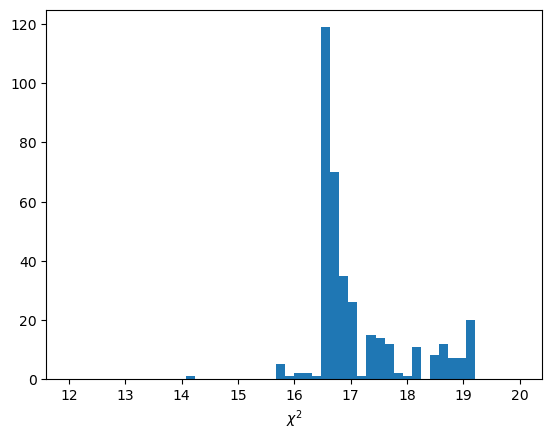

In [14]:
_ = plt.hist(y, bins=50, range=(12,20))
plt.xlabel(r'$\chi^2$')

Text(0, 0.5, '$\\chi^2$')

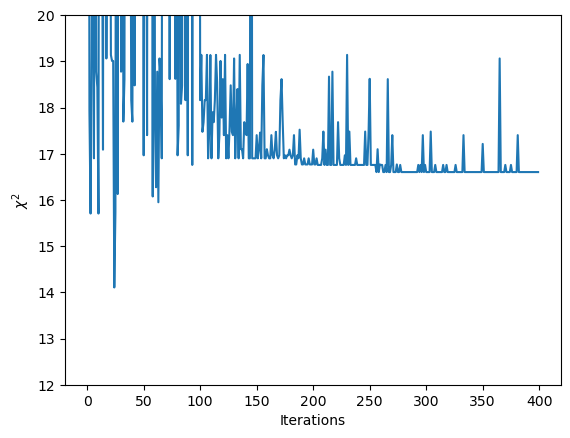

In [15]:
plt.plot(y[100:])
plt.ylim(12,20)
plt.xlabel('Iterations')
plt.ylabel(r'$\chi^2$')

Text(0, 0.5, '$c_{q_L}^{33}$')

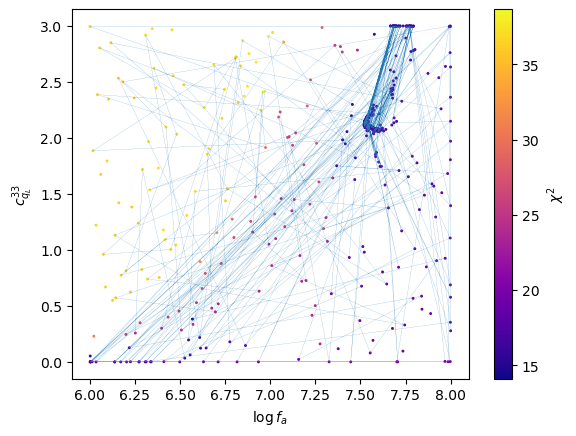

In [16]:
plt.plot(X[100:,0], X[100:,1], lw=0.1)
plt.scatter(X[:,0], X[:,1], s=1.2, c=y, cmap='plasma')
plt.colorbar(label=r'$\chi^2$')
plt.xlabel(r'$\log f_a$')
plt.ylabel(r'$c_{q_L}^{33}$')